In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style="whitegrid")

dataset_path = Path("../datasets/sentiment.csv")
df = pd.read_csv(dataset_path)
df["label"] = df["label"].astype(int)
df["sentiment"] = df["label"].map({1: "Positive", 0: "Negative"})
df["text_length"] = df["text"].astype(str).str.len()

print(dataset_path.resolve())
print(df.shape)
df.head()

/home/hydralgorithm/Desktop/CSE_mitlab/SEM2/dv_lab/datasets/sentiment.csv
(10, 4)


,text,label,sentiment,text_length
0,I love this phone it works perfectly,1,Positive,36
1,The product quality is excellent,1,Positive,32
2,Very happy with the purchase,1,Positive,28
3,This is the worst service ever,0,Negative,30
4,I hate this product,0,Negative,19


/tmp/ipykernel_81837/3486892614.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="sentiment", palette="Set2", ax=axes[0])
/tmp/ipykernel_81837/3486892614.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=summary, x="sentiment", y="avg_text_length", palette="Set2", ax=axes[1])


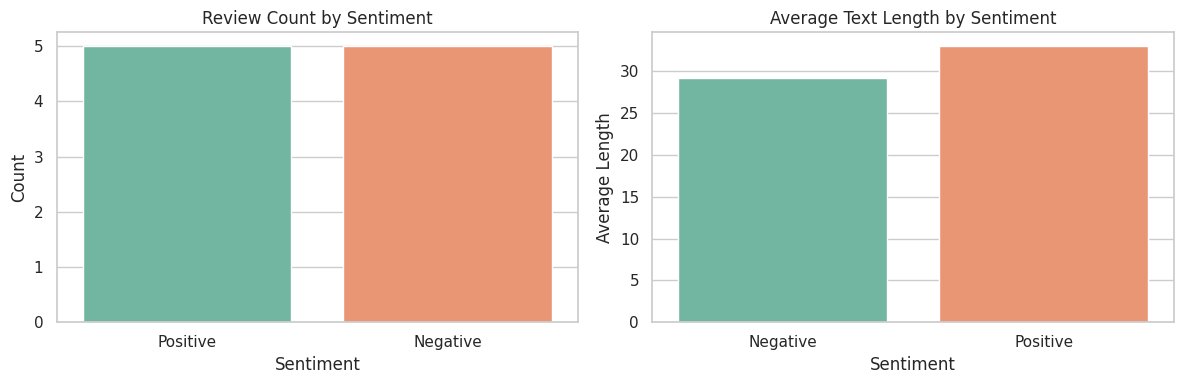

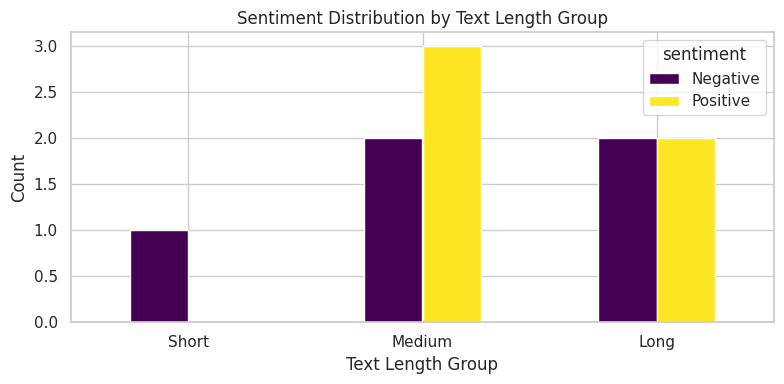

In [2]:
summary = df.groupby("sentiment").agg(
    reviews=("text", "count"),
    avg_text_length=("text_length", "mean"),
    min_text_length=("text_length", "min"),
    max_text_length=("text_length", "max")
).reset_index()
summary

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.countplot(data=df, x="sentiment", palette="Set2", ax=axes[0])
axes[0].set_title("Review Count by Sentiment")
axes[0].set_xlabel("Sentiment")
axes[0].set_ylabel("Count")

sns.barplot(data=summary, x="sentiment", y="avg_text_length", palette="Set2", ax=axes[1])
axes[1].set_title("Average Text Length by Sentiment")
axes[1].set_xlabel("Sentiment")
axes[1].set_ylabel("Average Length")

plt.tight_layout()
plt.show()

length_bins = pd.cut(df["text_length"], bins=[0, 20, 35, 60, 200], labels=["Short", "Medium", "Long", "Very Long"], include_lowest=True)
length_sentiment = pd.crosstab(length_bins, df["sentiment"])
length_sentiment

length_sentiment.plot(kind="bar", figsize=(8, 4), colormap="viridis")
plt.title("Sentiment Distribution by Text Length Group")
plt.xlabel("Text Length Group")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()